# Notebook 05 . Analyse de cadrage VSS x Immigration

## De quoi parle ce notebook ?

Ce notebook est le coeur de l'analyse. On s'intéresse aux phrases des débats parlementaires qui mentionnent
**en même temps** les violences sexistes et sexuelles (VSS) et l'immigration ou les minorités religieuses.
Pour chacune de ces phrases, on cherche à déterminer le **cadrage** utilisé par l'orateur :

| Cadrage | Ce que l'orateur fait |
|---|---|
| **ACCUSATEUR** | Il présente l'immigration ou l'islam comme la *cause* des VSS |
| **VICTIME** | Il présente les immigrés ou les minorités comme *victimes* de violences |
| **NEUTRE** | Il fait une mention administrative, factuelle, ou il dénonce l'amalgame |

On applique **quatre méthodes complémentaires**, de la plus simple à la plus sophistiquée,
pour vérifier que les résultats convergent.

## Les 4 méthodes en bref

1. **V1 . Lexique de cadrage** : on attribue un score en comptant des mots d'accusation, de menace, de causalité
2. **V2 . Patterns syntaxiques** : des expressions régulières qui détectent *qui fait quoi à qui* dans la phrase
3. **V3 . Zero-shot NLI** : un modèle CamemBERT qui comprend le sens de la phrase sans entraînement préalable
4. **V4 . Classification LLM** : Llama 3.3 analyse chaque phrase et produit une justification en langage naturel

## Données utilisées

On charge le fichier `df_vss_propre.pkl` produit par le notebook 02 (10 377 prises de parole filtrées et nettoyées).

## 0. Imports et chargement

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re, os, time
from collections import defaultdict, Counter
from tqdm import tqdm

# ==============================================================
# STYLE GRAPHIQUE
# ==============================================================

import matplotlib.pyplot as plt
import matplotlib as mpl

PALETTE_PASTEL = ["#A8D8EA", "#AA96DA", "#FCBAD3", "#FFFFD2", "#B5EAD7",
                  "#C7CEEA", "#FFB7B2", "#E2F0CB", "#FFDAC1", "#B5B8FF"]

COULEURS_BLOCS = {
    "Extrême Droite":        "#E88D9A",
    "Droite Traditionnelle": "#7BAFD4",
    "Centre":                "#F2CC8F",
    "Gauche Modérée":        "#81B29A",
    "Gauche Radicale":       "#D4A5A5",
}

ORDRE_BLOCS = ["Extrême Droite", "Droite Traditionnelle", "Centre", "Gauche Modérée", "Gauche Radicale"]

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'font.weight': 'light',
    'axes.titlesize': 13,
    'axes.titleweight': 'normal',
    'axes.labelsize': 11,
    'axes.labelweight': 'light',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#CCCCCC',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.color': '#DDDDDD',
    'legend.frameon': False,
    'legend.fontsize': 9,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'text.color': '#222222',
})

print("Style graphique chargé.")


chemin_propre = "/home/onyxia/work/projet_eco_socio/df_vss_propre.pkl"

if not os.path.exists(chemin_propre):
    print(f"Fichier introuvable a la racine, on cherche dans dataframes/...")
    chemin_propre = "/home/onyxia/work/projet_eco_socio/dataframes/df_vss_propre.pkl"

df_vss = pd.read_pickle(chemin_propre)
df_vss['date'] = pd.to_datetime(df_vss['date'])
df_vss = df_vss.dropna(subset=['bloc']).copy()

print(f"{len(df_vss)} prises de parole VSS chargées.")
for bloc in ORDRE_BLOCS:
    n = len(df_vss[df_vss['bloc'] == bloc])
    print(f"  {bloc:30s} : {n:5d}")

Style graphique chargé.
7815 prises de parole VSS chargées.
  Extrême Droite                 :   726
  Droite Traditionnelle          :  1470
  Centre                         :  2815
  Gauche Modérée                 :  1115
  Gauche Radicale                :  1689


### Vocabulaire de recherche

On définit les deux listes de racines de mots qui servent a détecter les cooccurrences :
les mots du champ **VSS** et ceux du champ **identitaire / migratoire**.

In [16]:
GROUPES_CIBLES = [
    "immigr", "clandestin", "étranger", "migrant", "réfugié", "exilé", "demandeur d'asile",
    "sans-papier", "sans papier", "oqtf", "expulsion", "frontière", "reconduite", "éloignement",
    "islam", "musulman", "charia", "voile", "abaya", "burqa", "qamis",
    "confession", "séparatisme", "communautarisme", "assimilation", "intégration",
    "maghrébin", "africain", "arabe", "origine étrangère", "civilisation",
    "ensauvagement", "décivilisation", "grand remplacement", "racaille", "délinquan"
]

MOTS_VSS = [
    "viol", "agress", "féminicide", "mutilation", "prostitu", "proxénét", "tournante",
    "harcel", "harcèl", "cyberharcèl", "cyber-harcèl",
    "sexuel", "sexis", "conjugal", "inceste", "pédocrimin", "pédophil",
    "patriarca", "misogyn", "machis", "emprise", "soumission", "consentement",
    "stéréotype", "domination masculine", "culture du viol", "me too", "metoo"
]

print(f"{len(GROUPES_CIBLES)} racines identitaires, {len(MOTS_VSS)} racines VSS.")

36 racines identitaires, 28 racines VSS.


## 1. Extraction des phrases de cooccurrence

Avant d'appliquer les 4 méthodes, il faut isoler les phrases qui parlent des deux sujets a la fois.
On utilise deux modes complémentaires :

- **Mode direct** : les deux vocabulaires apparaissent dans la même phrase
- **Mode fenêtre** : un mot VSS dans une phrase, un mot identitaire dans une phrase voisine (plus ou moins 2 phrases)

Le mode fenêtre est important car un député peut dire "ces agressions sexuelles sont inadmissibles"
dans une phrase, puis "et ce sont des étrangers sous OQTF" dans la suivante.

In [17]:
def extraire_contextes(df_vss, fenetre_phrases=2):
    pat_groupe = re.compile(
        r"(?i)\b(" + "|".join([re.escape(m) for m in GROUPES_CIBLES]) + r")\w*\b"
    )
    pat_vss = re.compile(
        r"(?i)\b(" + "|".join([re.escape(m) for m in MOTS_VSS]) + r")\w*\b"
    )

    resultats = []
    for _, row in tqdm(df_vss.iterrows(), total=len(df_vss), desc="Extraction"):
        texte = str(row.get("texte", ""))
        bloc = row.get("bloc")
        if not texte or pd.isna(bloc):
            continue
        phrases = [p.strip() for p in re.split(r"[.!?;]+", texte) if len(p.strip().split()) >= 5]
        n = len(phrases)
        for i, phrase in enumerate(phrases):
            a_vss = bool(pat_vss.search(phrase))
            a_groupe = bool(pat_groupe.search(phrase))
            if a_vss and a_groupe:
                resultats.append({
                    "contexte": phrase, "bloc": bloc,
                    "nom_parti": row.get("nom_parti"), "date": row.get("date"),
                    "mode": "directe"
                })
            elif a_vss:
                debut = max(0, i - fenetre_phrases)
                fin = min(n, i + fenetre_phrases + 1)
                voisines = phrases[debut:i] + phrases[i+1:fin]
                if any(pat_groupe.search(v) for v in voisines):
                    resultats.append({
                        "contexte": " ".join(phrases[debut:fin]), "bloc": bloc,
                        "nom_parti": row.get("nom_parti"), "date": row.get("date"),
                        "mode": "fenetre"
                    })

    df = pd.DataFrame(resultats).drop_duplicates(subset="contexte")
    print(f"\n{len(df)} contextes extraits ({df['mode'].value_counts().to_dict()})")
    return df

df_contextes = extraire_contextes(df_vss)

Extraction: 100%|██████████| 7815/7815 [00:05<00:00, 1479.29it/s]


588 contextes extraits ({'fenetre': 350, 'directe': 238})


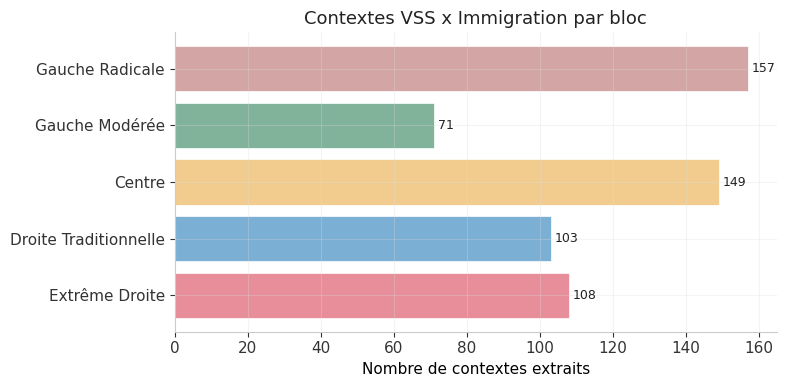

In [18]:
# Répartition des contextes par bloc
fig, ax = plt.subplots(figsize=(8, 4))
counts = df_contextes['bloc'].value_counts().reindex(ORDRE_BLOCS).fillna(0)
colors = [COULEURS_BLOCS[b] for b in counts.index]
ax.barh(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.5)
for i, v in enumerate(counts.values):
    ax.text(v + 1, i, f"{int(v)}", va='center', fontsize=9)
ax.set_xlabel("Nombre de contextes extraits")
ax.set_title("Contextes VSS x Immigration par bloc")
plt.tight_layout()
plt.show()

### Fonctions de visualisation communes

In [19]:
def tracer_barres_empilees(df, col_cadrage, titre=""):
    blocs_presents = [b for b in ORDRE_BLOCS if b in df["bloc"].unique()]
    counts = (df.groupby(["bloc", col_cadrage]).size()
              .unstack(fill_value=0).reindex(blocs_presents))
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    for col in ["ACCUSATEUR", "NEUTRE", "VICTIME", "AMBIGU"]:
        if col not in pct.columns:
            pct[col] = 0

    coul = {"ACCUSATEUR": "#E88D9A", "AMBIGU": "#F2CC8F", "NEUTRE": "#C7CEEA", "VICTIME": "#7BAFD4"}
    fig, ax = plt.subplots(figsize=(10, 6))
    bottom = np.zeros(len(pct))
    cats = [c for c in ["ACCUSATEUR", "AMBIGU", "NEUTRE", "VICTIME"] if pct[c].sum() > 0]
    for cat in cats:
        vals = pct[cat].values
        ax.bar(pct.index, vals, bottom=bottom, color=coul.get(cat, "#DDD"),
               label=cat, edgecolor="white", lw=0.8)
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 4:
                ax.text(i, b + v/2, f"{v:.0f}%", ha="center", va="center",
                        fontsize=9, color="#333")
        bottom += vals
    ax.set_ylim(0, 100)
    ax.set_ylabel("Part des contextes (%)")
    ax.set_title(titre)
    ax.set_xticks(range(2018, 2025))
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()


def tracer_score_net(df, col_score, titre=""):
    stats = (df.groupby("bloc")[col_score]
             .agg(["mean", "sem", "count"])
             .rename(columns={"mean": "m", "sem": "e", "count": "n"})
             .reset_index())
    stats = stats[stats["bloc"].isin(ORDRE_BLOCS)]
    stats["bloc"] = pd.Categorical(stats["bloc"], categories=ORDRE_BLOCS, ordered=True)
    stats = stats.sort_values("bloc")
    couleurs = [COULEURS_BLOCS.get(b, "#DDD") for b in stats["bloc"]]

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(stats["bloc"], stats["m"], xerr=stats["e"], color=couleurs,
            edgecolor="white", capsize=3, linewidth=0.8,
            error_kw={"elinewidth": 1, "ecolor": "#999", "capthick": 1})
    ax.axvline(0, color="#999", lw=1)
    ax.fill_betweenx(range(-1, len(stats)+1), -1.5, 0, alpha=0.03, color="#7BAFD4")
    ax.fill_betweenx(range(-1, len(stats)+1), 0, 1.5, alpha=0.03, color="#E88D9A")
    for i, row in enumerate(stats.itertuples()):
        x = row.m
        ax.text(x + (0.01 if x >= 0 else -0.01), i,
                f"  {x:.3f}  (n={int(row.n)})",
                va="center", ha="left" if x >= 0 else "right", fontsize=9)
    ax.set_title(titre)
    ax.set_xticks(range(2018, 2025))
    ax.set_xlabel("protecteur / victime  .  accusateur")
    plt.tight_layout()
    plt.show()


def tracer_evolution(df, col_score, titre=""):
    d = df.copy()
    d["date"] = pd.to_datetime(d["date"], errors="coerce")
    d["annee"] = d["date"].dt.year
    d = d.dropna(subset=["annee"])
    evol = d.groupby(["annee", "bloc"])[col_score].mean().reset_index()
    evol = evol[evol["bloc"].isin(ORDRE_BLOCS)]

    fig, ax = plt.subplots(figsize=(11, 6))
    for bloc in ORDRE_BLOCS:
        sub = evol[evol["bloc"] == bloc].sort_values("annee")
        if sub.empty:
            continue
        ax.plot(sub["annee"], sub[col_score], marker="o", label=bloc,
                color=COULEURS_BLOCS.get(bloc, "#DDD"), lw=2, markersize=6)
    ax.axhline(0, color="#999", lw=1, ls="--")
    ax.set_title(titre)
    ax.set_xlabel("Année")
    ax.set_xticks(range(2018, 2025))
    ax.set_ylabel("Score net moyen")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


def afficher_exemples(df, col_cadrage, n=2):
    print("\n" + "=" * 80)
    print("VALIDATION QUALITATIVE")
    print("=" * 80)
    for bloc in ORDRE_BLOCS:
        sub = df[df["bloc"] == bloc]
        if sub.empty:
            continue
        print(f"\n{'.'*65}")
        print(f"  {bloc.upper()} . {len(sub)} contextes")
        print(f"  {sub[col_cadrage].value_counts().to_dict()}")
        for cadrage in ["ACCUSATEUR", "VICTIME"]:
            sous = sub[sub[col_cadrage] == cadrage].head(n)
            if sous.empty:
                continue
            print(f"\n  [{cadrage}]")
            for _, row in sous.iterrows():
                txt = str(row["contexte"])[:250]
                print(f"    [{row.get('nom_parti', '?')}] \"{txt}...\"")
                if "justification" in row and pd.notna(row.get("justification")):
                    print(f"    > {str(row['justification'])[:150]}")
    print()

## 2. Methode V1 . Lexique de cadrage-menace

La première approche est purement lexicale. On définit un dictionnaire de patterns regroupés en 4 catégories,
chacune ayant un poids différent :

- **Causalité directe** (poids 3) : "a cause de l'immigration", "importé", "commis par des étrangers"
- **Accusation de groupe** (poids 2) : "les immigrés", "leur culture", "ces étrangers"
- **Rhétorique de la menace** (poids 2) : "invasion", "ensauvagement", "nos femmes"
- **Opposition nous/eux** (poids 1) : "chez nous", "nos valeurs", "leur conception"

Cette méthode est rapide et explicable, mais elle a un défaut important :
elle ne distingue pas "les musulmans agressent" de "les musulmans sont agressés".
C'est pour corriger cette limite qu'on a développé la méthode V2.

In [20]:
CADRAGE_MENACE = {
    "causalite": [
        "à cause de", "en raison de", "provoqué par", "causé par", "viennent de",
        "importé", "importée", "venu d'ailleurs", "venu de l'étranger",
        "lié à l'immigration", "lié aux migrants", "due à l'immigration",
        "issus de l'immigration", "commis par des", "perpétré par des",
        "commis par des étrangers", "auteurs étrangers", "agresseurs étrangers"
    ],
    "accusation_groupe": [
        "les immigrés", "ces étrangers", "ces migrants", "les clandestins",
        "ces hommes venus", "certaines cultures", "certaines religions",
        "communautés", "les musulmans", "leur culture", "leur religion",
        "leur pays d'origine", "pratiques culturelles", "pratiques religieuses",
        "mentalité", "vision de la femme"
    ],
    "rhetorique_menace": [
        "invasion", "submersion", "grand remplacement", "ensauvagement",
        "insécurité", "danger", "menace", "protéger", "défendre",
        "nos femmes", "nos filles", "notre pays", "notre identité",
        "laxisme", "frontières ouvertes", "immigration incontrôlée"
    ],
    "nous_eux": [
        "chez nous", "en france", "notre société", "nos valeurs",
        "leur conception", "leur rapport", "contrairement à nous",
        "mentalité différente", "pays d'origine", "culture d'origine"
    ]
}
POIDS = {"causalite": 3, "accusation_groupe": 2, "rhetorique_menace": 2, "nous_eux": 1}

def scorer_v1(texte):
    t = texte.lower()
    score = sum(POIDS[cat] for cat, mots in CADRAGE_MENACE.items() for mot in mots if mot in t)
    return score

df_v1 = df_contextes.copy()
df_v1['score_menace'] = df_v1['contexte'].apply(scorer_v1)
df_v1['cadrage_v1'] = np.where(df_v1['score_menace'] > 2, "ACCUSATEUR",
                      np.where(df_v1['score_menace'] == 0, "NEUTRE", "NEUTRE"))
df_v1['score_net_v1'] = np.where(df_v1['score_menace'] > 2, 1, 0)

print("Distribution V1 :")
print(df_v1['cadrage_v1'].value_counts().to_string())

Distribution V1 :
cadrage_v1
NEUTRE        539
ACCUSATEUR     49


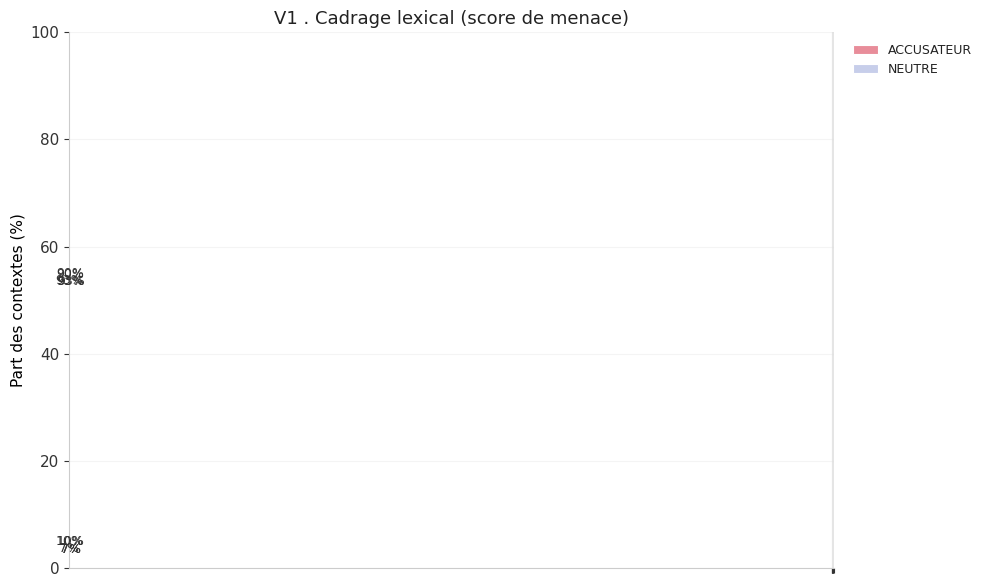

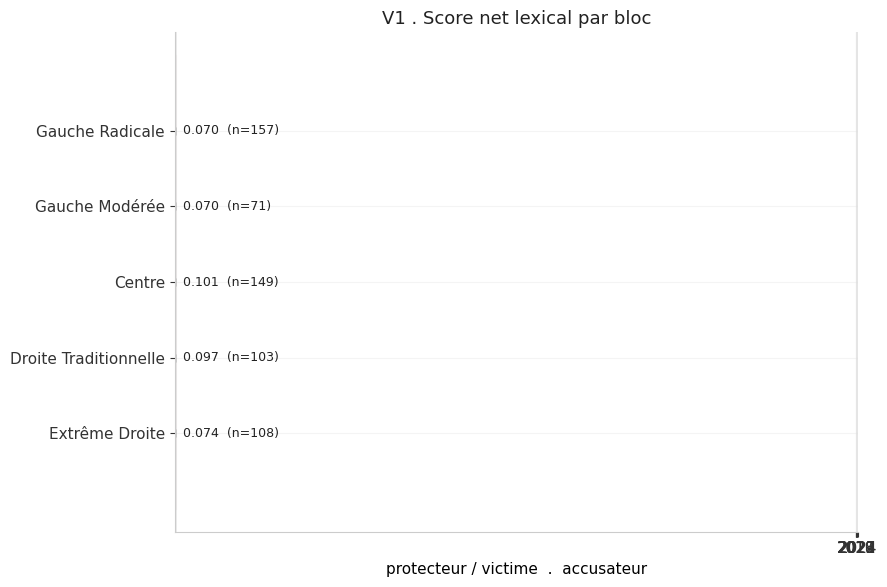


VALIDATION QUALITATIVE

.................................................................
  EXTRÊME DROITE . 108 contextes
  {'NEUTRE': 100, 'ACCUSATEUR': 8}

  [ACCUSATEUR]
    [Rassemblement national] "Parce que, si ce texte a vocation à défendre les principes de la République, les votes des députés du groupe La République en Marche sont, sans le moindre doute, révélateurs de l’idée qu’Emmanuel Macron se fait de l’évolution que doit connaître notre..."
    [Rassemblement national] "Et que dire de ces associations – financées par l’État – qui gèrent les logements d’urgence et qui refusent de mettre à la rue les déboutés du droit d’asile, eux-mêmes refusant de quitter le territoire national Pendant ce temps, certains des véritabl..."

.................................................................
  DROITE TRADITIONNELLE . 103 contextes
  {'NEUTRE': 93, 'ACCUSATEUR': 10}

  [ACCUSATEUR]
    [Les Républicains] "Le secret de la confession, qui figure dans notre droit depuis quasiment 

In [52]:
tracer_barres_empilees(df_v1, "cadrage_v1", "V1 . Cadrage lexical (score de menace)")
tracer_score_net(df_v1, "score_net_v1", "V1 . Score net lexical par bloc")
afficher_exemples(df_v1, "cadrage_v1", n=2)

## 3. Methode V2 . Patterns syntaxiques orientés rôle

Le problème de V1, c'est qu'elle ne sait pas *qui fait quoi*. La V2 utilise des expressions régulières
qui tiennent compte de la **structure sujet-verbe-objet** pour déterminer si le groupe cible
(immigrés, musulmans...) est en position d'**agent** (il agresse) ou de **patient** (il est agressé).

On cherche aussi les patterns de **dénonciation d'amalgame** (stigmatisation, bouc émissaire, instrumentalisation),
qui sont classés comme VICTIME/NEUTRE car l'orateur ne porte pas l'accusation, il la réfute.

In [21]:
PATTERNS_ACCUSATEUR = [
    r"(immigr\w*|clandestin\w*|étranger\w*|migrant\w*|musulman\w*|arabe\w*)"
    r"[\w\s,]{0,30}(viol\w*|agress\w*|maltraitent|commettent|perpètrent|battent|frappent|tuent)",
    r"(violences?|viols?|agressions?)[\w\s,]{0,20}(commis|perpétr|fait|exerc)\w*"
    r"[\w\s,]{0,15}(immigr\w*|clandestin\w*|étranger\w*|musulman\w*|arabe\w*)",
    r"(à cause de|en raison de|du fait de|liés? à)[\w\s]{0,20}(l.immigration|clandestin|leur culture|l.islam)",
    r"(import[ée]\w*|venu[e]? d.ailleurs|étranger[eès]? à notre)",
    r"(nos femmes|nos filles|nos enfants)[\w\s,]{0,30}(protéger|défendre|menac\w*|danger)",
    r"(invasion|ensauvagement|grand remplacement|submersion|islamisation)",
    r"(leur culture|leur mentalité|leur rapport à la femme|leur vision de la femme)",
    r"(étranger\w*|immigr\w*).{0,30}condamné\w*.{0,20}(viol|agress)",
]
PATTERNS_VICTIME = [
    r"(immigr\w*|étranger\w*|migrant\w*|musulman\w*|sans-papier\w*|réfugié\w*)"
    r"[\w\s,]{0,30}(victimes?|subiss\w*|agress[ée]\w*|discrimin\w*|exposés?)",
    r"(protéger|défendre|accompagner|soutenir|aider)"
    r"[\w\s]{0,20}(immigr\w*|migrant\w*|sans-papier\w*|réfugiées?)",
    r"(doublement|vulnérable|précaire|plus exposée|davantage exposée)",
    r"(bouc[s]? émissaire[s]?|stigmatis\w*|diabolis\w*|montré[s]? du doigt)",
    r"(amalgam\w*|instrumentalis\w*|récupération (politique|électorale|identitaire))",
    r"(ne|n.?) (faut|peut|doit)\w* pas.{0,30}lien",
]

def scorer_v2(phrase):
    t = phrase.lower()
    n_acc = sum(1 for p in PATTERNS_ACCUSATEUR if re.search(p, t, re.I | re.DOTALL))
    n_vic = sum(1 for p in PATTERNS_VICTIME if re.search(p, t, re.I | re.DOTALL))
    score = n_acc - n_vic
    if n_acc == 0 and n_vic == 0: cadrage = "NEUTRE"
    elif n_acc > n_vic: cadrage = "ACCUSATEUR"
    elif n_vic > n_acc: cadrage = "VICTIME"
    else: cadrage = "NEUTRE"
    return {"score_net_v2": score, "cadrage_v2": cadrage}

scores = df_contextes["contexte"].apply(scorer_v2)
df_v2 = pd.concat([df_contextes.reset_index(drop=True), pd.DataFrame(scores.tolist())], axis=1)
print("Distribution V2 :")
print(df_v2['cadrage_v2'].value_counts().to_string())

Distribution V2 :
cadrage_v2
NEUTRE        536
VICTIME        31
ACCUSATEUR     21


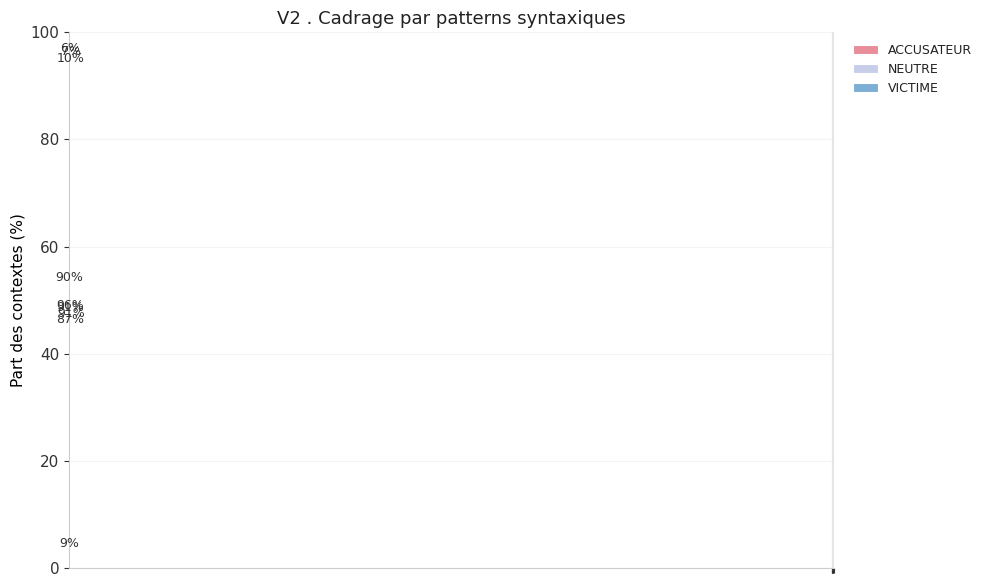

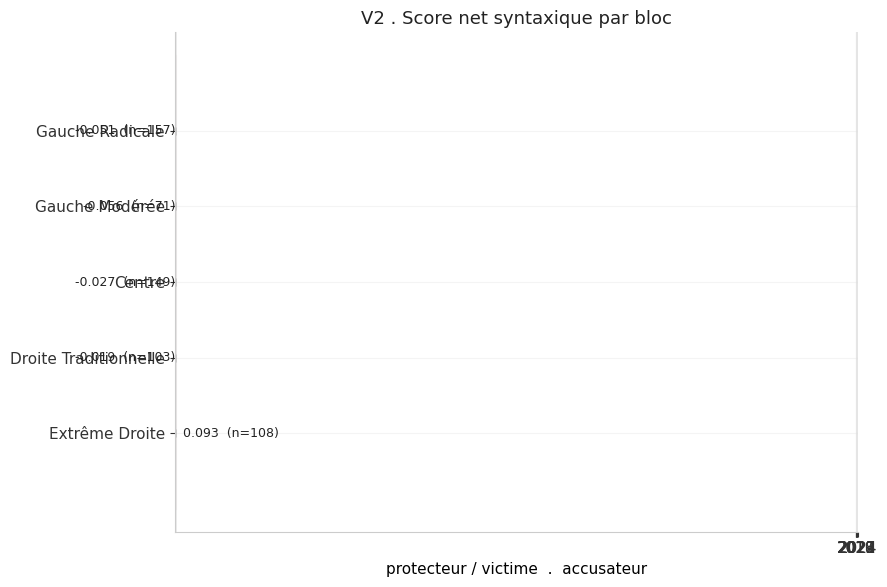

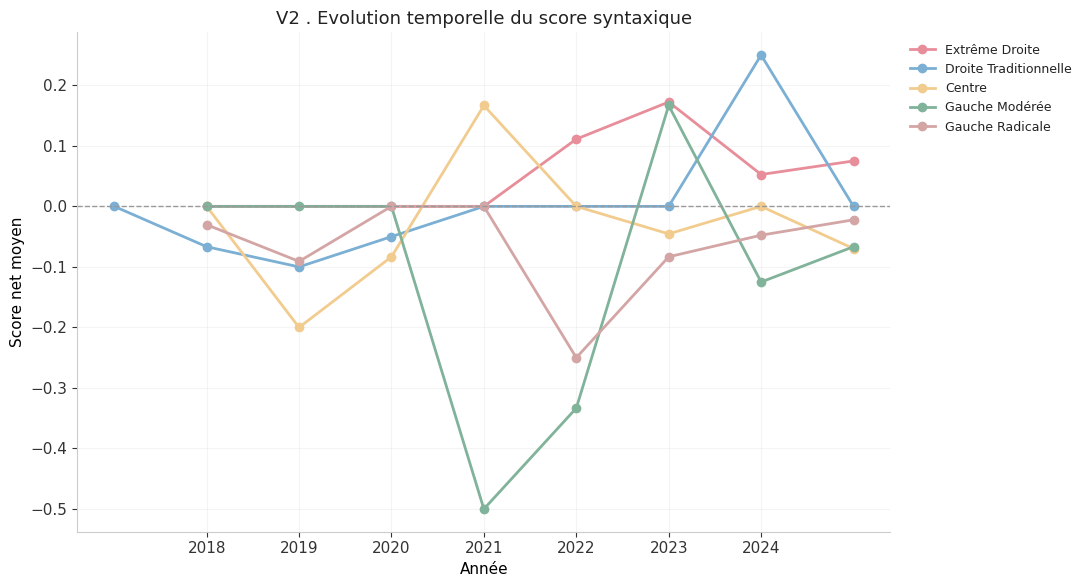


VALIDATION QUALITATIVE

.................................................................
  EXTRÊME DROITE . 108 contextes
  {'NEUTRE': 97, 'ACCUSATEUR': 10, 'VICTIME': 1}

  [ACCUSATEUR]
    [Rassemblement national] "Et que dire de ces associations – financées par l’État – qui gèrent les logements d’urgence et qui refusent de mettre à la rue les déboutés du droit d’asile, eux-mêmes refusant de quitter le territoire national Pendant ce temps, certains des véritabl..."
    [Rassemblement national] "Cet amendement de Marine Le Pen entend inscrire le respect de tous les citoyens dans notre texte fondamental, au-delà des particularités qui peuvent certes les distinguer dans leur personnalité mais en aucun cas dans leur citoyenneté L’égalité de cha..."

  [VICTIME]
    [Rassemblement national] "Ces éléments tangibles viennent avec beaucoup, si ce n’est énormément, de communication, sur tous les sujets susceptibles d’émouvoir l’opinion publique : harcèlement, abaya, laïcité, violence, autor

In [54]:
tracer_barres_empilees(df_v2, "cadrage_v2", "V2 . Cadrage par patterns syntaxiques")
tracer_score_net(df_v2, "score_net_v2", "V2 . Score net syntaxique par bloc")
tracer_evolution(df_v2, "score_net_v2", "V2 . Evolution temporelle du score syntaxique")
afficher_exemples(df_v2, "cadrage_v2", n=2)

## 4. Methode V3 . Classification Zero-Shot (CamemBERT NLI)

On passe maintenant aux méthodes de deep learning. Le modèle `cmarkea/distilcamembert-base-nli`
est un CamemBERT distillé, fine-tuné sur des tâches d'inférence en langage naturel.

On lui donne la phrase et trois hypothèses, et il attribue une probabilité a chacune.
Contrairement a V1 et V2, ce modèle comprend le **sens** de la phrase :
il fait la différence entre "les musulmans agressent" et "les musulmans sont agressés".

(Les résultats sont sauvegardés en pickle pour ne pas relancer le modèle a chaque exécution.)

In [22]:
import subprocess, sys
try:
    import torch
    from transformers import pipeline as hf_pipeline
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch", "transformers", "sentencepiece"])
    import torch
    from transformers import pipeline as hf_pipeline
print(f"GPU disponible : {torch.cuda.is_available()}")

GPU disponible : False


In [23]:
output_v3 = "/home/onyxia/work/projet_eco_socio/analyses/cadrage_v3_zeroshot"
os.makedirs(output_v3, exist_ok=True)
chemin_v3 = os.path.join(output_v3, "df_cadrage_v3.pkl")

if os.path.exists(chemin_v3):
    df_v3 = pd.read_pickle(chemin_v3)
    print(f"Resultats V3 charges depuis le cache : {len(df_v3)} contextes.")
else:
    device = 0 if torch.cuda.is_available() else -1
    classifier = hf_pipeline("zero-shot-classification",
                              model="cmarkea/distilcamembert-base-nli", device=device)

    LABELS = ["une accusation contre l'immigration et l'islam",
              "une défense des immigrés et des minorités",
              "une critique de la droite ou un constat neutre"]
    MAP = {LABELS[0]: "ACCUSATEUR", LABELS[1]: "VICTIME", LABELS[2]: "NEUTRE"}

    resultats = []
    for _, row in tqdm(df_contextes.iterrows(), total=len(df_contextes), desc="CamemBERT NLI"):
        try:
            out = classifier(row["contexte"][:512], LABELS, hypothesis_template="Ce texte exprime {}.")
            cadrage = MAP[out['labels'][0]]
            confiance = out['scores'][0]
        except Exception:
            cadrage, confiance = "NEUTRE", 0.33
        score = {"ACCUSATEUR": 1, "VICTIME": -1}.get(cadrage, 0)
        resultats.append({"cadrage_v3": cadrage, "score_net_v3": score, "confiance_v3": confiance})

    df_v3 = pd.concat([df_contextes.reset_index(drop=True), pd.DataFrame(resultats)], axis=1)
    df_v3.to_pickle(chemin_v3)

print("Distribution V3 :")
print(df_v3['cadrage_v3'].value_counts().to_string())

Resultats V3 charges depuis le cache : 241 contextes.
Distribution V3 :
cadrage_v3
NEUTRE        197
ACCUSATEUR     28
VICTIME        16


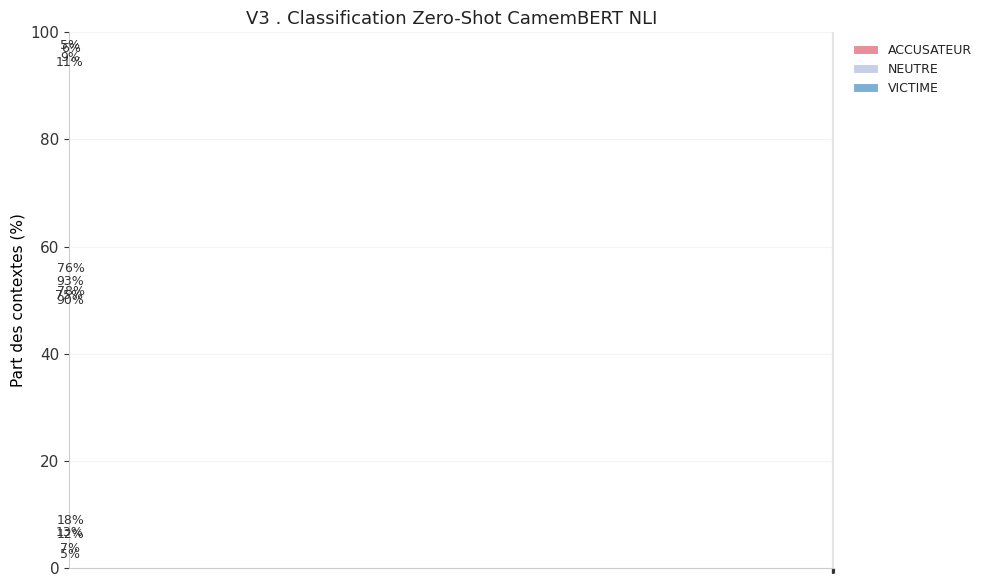

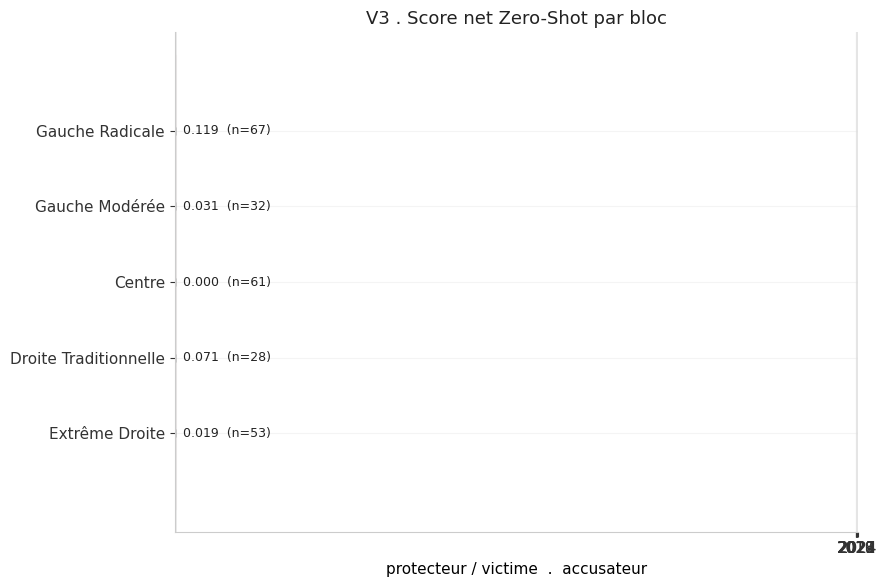

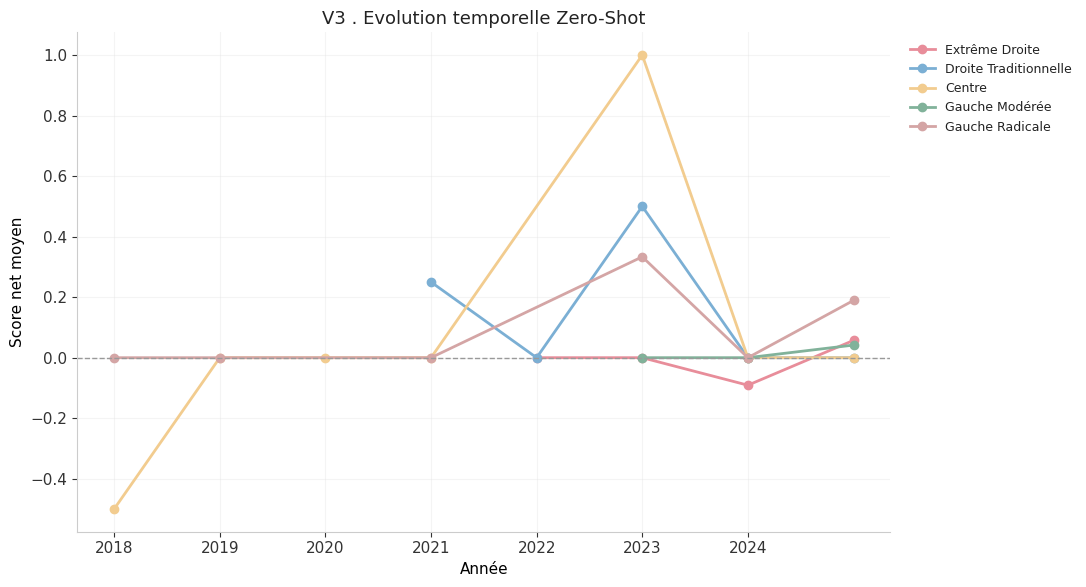


VALIDATION QUALITATIVE

.................................................................
  EXTRÊME DROITE . 53 contextes
  {'NEUTRE': 40, 'ACCUSATEUR': 7, 'VICTIME': 6}

  [ACCUSATEUR]
    [Rassemblement national] "De toute façon, plus personne n’ignore que votre soutien sans limite à l’immigration est le terreau du communautarisme islamiste, de l’expansion de la charia et de la banalisation du viol..."
    [Rassemblement national] "…et qui s’est illustrée par la défense du Collectif – islamiste – contre l’islamophobie en France (CCIF) et de l’imam antisémite et sexiste Hassan Iquioussen..."

  [VICTIME]
    [Rassemblement national] "En revanche, nous voulons qu’un étranger soit expulsé s’il se rend coupable de proxénétisme, de viol, de meurtre, de harcèlement sexuel aggravé, de diffusion de messages pornographiques à des mineurs, de menace de mort ou encore d’abus de faiblesse s..."
    [Rassemblement national] "Si vous étiez réellement féministes, vous vous seriez rendus disponible

In [24]:
tracer_barres_empilees(df_v3, "cadrage_v3", "V3 . Classification Zero-Shot CamemBERT NLI")
tracer_score_net(df_v3, "score_net_v3", "V3 . Score net Zero-Shot par bloc")
tracer_evolution(df_v3, "score_net_v3", "V3 . Evolution temporelle Zero-Shot")
afficher_exemples(df_v3, "cadrage_v3", n=2)

## 5. Methode V4 . Classification par LLM (Llama 3.3 via Open WebUI ENSAE)

On envoie chaque contexte a Llama 3.3 (70B parametres),
hébergé sur les GPU du Groupe GENES. Le modèle analyse la phrase, comprend les nuances
rhétoriques (ironie, dénonciation, sous-entendus), et produit une justification.

Depuis la mise a jour du service LLM de l'ENSAE, l'accès passe par **Open WebUI**
avec une clé API personnelle. L'ancienne URL directe (`ollama-api.lab.groupe-genes.fr/api/chat`)
n'est plus disponible sans authentification.



### 5.1 Configuration de l'API

In [155]:
import requests
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# ============================================================================
# CONFIGURATION API ENSAE (Open WebUI)
# ============================================================================
# Depuis la mise a jour du service, l'API nécessite une clé personnelle.
# Voir : https://dsit.pages.lab.groupe-genes.fr/documentation/services/llm/


API_KEY = "sk-2a48a7942fe04b8d9300c890ee48d2bc"
BASE_URL = "https://llm.lab.groupe-genes.fr"
MODELE_CHOISI = "mistral:latest"

print(f"URL    : {BASE_URL}")
print(f"Modele : {MODELE_CHOISI}")

URL    : https://llm.lab.groupe-genes.fr
Modele : mistral:latest


### 5.2 Vérification des modèles disponibles

In [26]:
try:
    r = requests.get(
        f"{BASE_URL}/ollama/api/tags",
        headers={"Authorization": f"Bearer {API_KEY}"},
        timeout=10,
        verify = False
    )
    modeles = r.json().get('models', [])
    print("Modeles disponibles sur le serveur ENSAE :\n")
    for m in modeles:
        print(f"  - {m['name']}")
except Exception as e:
    print(f"Erreur de connexion : {e}")
    print("Verifiez votre cle API et votre connexion.")

Modeles disponibles sur le serveur ENSAE :

  - llama3.3:latest
  - mistral:latest
  - gpt-oss:20b


### 5.3 Fonctions d'appel au LLM

In [67]:
PROMPT_SYSTEME = (
    "Tu es un chercheur en sociologie politique expert en analyse de discours parlementaire français. "
    "Analyse le contexte fourni (extrait d'un débat à l'Assemblée Nationale) et détermine "
    "le cadrage utilisé par l'orateur concernant le lien entre immigration/minorités et "
    "violences sexistes/sexuelles (VSS).\n\n"

    "PIEGES FREQUENTS A EVITER ABSOLUMENT :\n"
    "- DENONCIATION : Si l'orateur critique l'amalgame immigration-VSS, parle de "
    "stigmatisation, amalgame, récit mensonger, ou défend les immigrés contre des accusations : "
    "=> NEUTRE (l'orateur ne porte PAS l'accusation, il la réfute).\n"
    "- VOIX PASSIVE : Si un étranger ou une minorité subit, est agressé(e), est victime "
    "=> VICTIME (pas ACCUSATEUR).\n"
    "- ADMINISTRATIF : Conditions d'éloignement, titres de séjour, droit d'asile => NEUTRE.\n"
    "- CONTEXTE ANTI-RACISTE : Phrases dénonçant le racisme ou l'islamophobie => NEUTRE.\n\n"

    "TROIS CATEGORIES EXCLUSIVES :\n"
    "  ACCUSATEUR : L'orateur affirme que l'immigration ou l'islam CAUSE les VSS.\n"
    "  VICTIME    : L'orateur présente les immigrés/minorités comme VICTIMES.\n"
    "  NEUTRE     : Réfutation, fait administratif, sans lien causal.\n\n"

    "REPONSE OBLIGATOIRE en exactement 2 lignes :\n"
    "ANALYSE : [justification courte]\n"
    "CATEGORIE : [ACCUSATEUR ou VICTIME ou NEUTRE]"
)


def appeler_llm(prompt_user, max_retries=6):
    """Appel au LLM via Open WebUI (nouveau format avec clé API)."""
    payload = {
        "model": MODELE_CHOISI,
        "messages": [
            {"role": "system", "content": PROMPT_SYSTEME},
            {"role": "user", "content": prompt_user},
        ],
        "stream": False,
        "options": {"temperature": 0.0},
    }
    for attempt in range(max_retries):
        try:
            r = requests.post(
                f"{BASE_URL}/ollama/api/chat",
                headers={
                    "Authorization": f"Bearer {API_KEY}",
                    "Content-Type": "application/json"
                },
                json=payload,
                timeout=120
            )
            r.raise_for_status()
            return r.json()["message"]["content"]
        except requests.exceptions.HTTPError as e:
            code_http = e.response.status_code
            if code_http == 504:
                print(f"\n  [504] Serveur saturé, attente 60s... (tentative {attempt+1}/{max_retries})")
                time.sleep(60)
            else:
                print(f"\n  [HTTP {code_http}] Erreur, attente 15s...")
                time.sleep(15)
        except requests.exceptions.RequestException as e:
            print(f"\n  Erreur connexion ({e}). Attente 30s... (tentative {attempt+1}/{max_retries})")
            time.sleep(30)
        except ValueError:
            print(f"\n  Reponse non-JSON. Attente 15s...")
            time.sleep(15)
    print("  Echec definitif pour ce contexte. On le saute.")
    return ""


def parser_reponse(reponse):
    cadrage, score_net, justification = "NEUTRE", 0, reponse
    match_cat = re.search(r"CATEGORIE\s*:\s*(ACCUSATEUR|VICTIME|NEUTRE)", reponse, re.I)
    if match_cat:
        cadrage = match_cat.group(1).upper()
        if cadrage == "ACCUSATEUR": score_net = 1
        elif cadrage == "VICTIME": score_net = -1
    match_ana = re.search(r"ANALYSE\s*:\s*(.*?)(?=\nCATEGORIE|$)", reponse, re.I | re.DOTALL)
    if match_ana:
        justification = match_ana.group(1).strip()
    return cadrage, score_net, justification

print("Fonctions LLM prêtes.")

Fonctions LLM prêtes.


### 5.4 Classification avec reprise CSV

In [32]:
output_v4 = "/home/onyxia/work/projet_eco_socio/analyses/cadrage_v4_llm"
os.makedirs(output_v4, exist_ok=True)
fichier_csv = os.path.join(output_v4, "phrases_classifiees_llm.csv")

# Reprise depuis CSV existant
phrases_deja_faites = []
if os.path.exists(fichier_csv):
    df_existant = pd.read_csv(fichier_csv)
    phrases_deja_faites = df_existant['contexte'].tolist()
    print(f"Reprise : {len(phrases_deja_faites)} contextes deja classifies.")
else:
    colonnes = list(df_contextes.columns) + ['cadrage_llm', 'score_net_v4', 'justification', 'reponse_brute']
    pd.DataFrame(columns=colonnes).to_csv(fichier_csv, index=False, encoding='utf-8-sig')

df_a_traiter = df_contextes[~df_contextes['contexte'].isin(phrases_deja_faites)]
print(f"{len(df_a_traiter)} contextes restants a classifier.\n")

for _, row in tqdm(df_a_traiter.iterrows(), total=len(df_a_traiter), desc=f"Classification {MODELE_CHOISI}"):
    prompt = (
        f"Parti de l'orateur : '{row['nom_parti']}'\n"
        f"Contexte :\n\"{row['contexte']}\"\n\n"
        "Fournis ton ANALYSE puis ta CATEGORIE."
    )
    reponse = appeler_llm(prompt)
    if not reponse:
        continue

    cadrage, score_net, justification = parser_reponse(reponse)

    ligne = row.to_dict()
    ligne.update({'cadrage_llm': cadrage, 'score_net_v4': score_net,
                  'justification': justification, 'reponse_brute': reponse})
    pd.DataFrame([ligne]).to_csv(fichier_csv, mode='a', header=False, index=False, encoding='utf-8-sig')
    time.sleep(0.5)

df_v4 = pd.read_csv(fichier_csv)
df_v4['cadrage_llm'] = df_v4['cadrage_llm'].astype(str).str.upper().str.strip()
df_v4['cadrage_llm'] = df_v4['cadrage_llm'].where(
    df_v4['cadrage_llm'].isin(['ACCUSATEUR', 'VICTIME', 'NEUTRE']), 'NEUTRE')
df_v4['score_net_v4'] = df_v4['cadrage_llm'].map({'ACCUSATEUR': 1, 'VICTIME': -1, 'NEUTRE': 0})

print(f"\nClassification V4 terminée : {len(df_v4)} contextes.")
print(df_v4['cadrage_llm'].value_counts().to_string())

Reprise : 588 contextes deja classifies.
0 contextes restants a classifier.



Classification llama3.3:70b: 0it [00:00, ?it/s]


Classification V4 terminée : 588 contextes.
cadrage_llm
NEUTRE        469
ACCUSATEUR     68
VICTIME        51


### 5.5 Visualisations V4

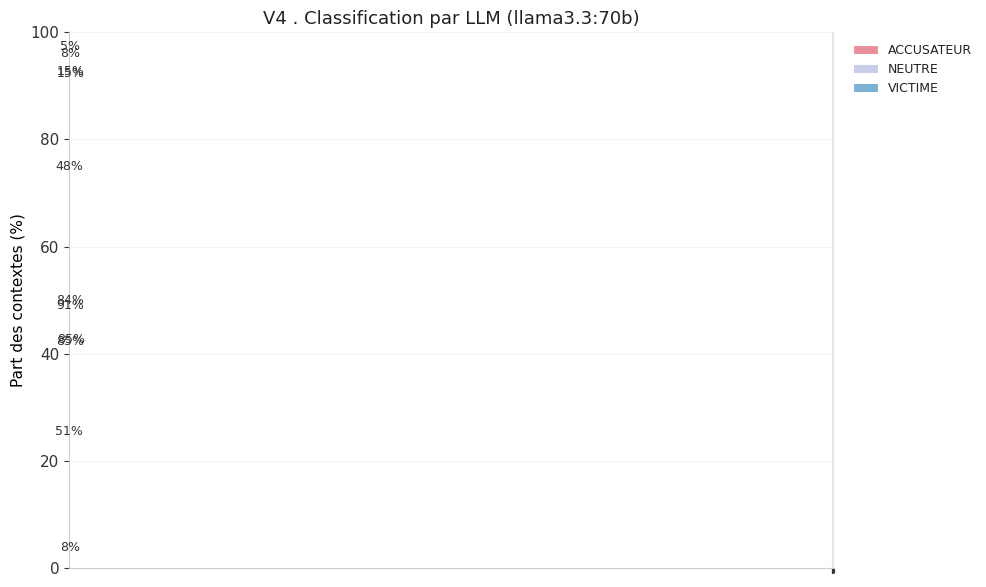

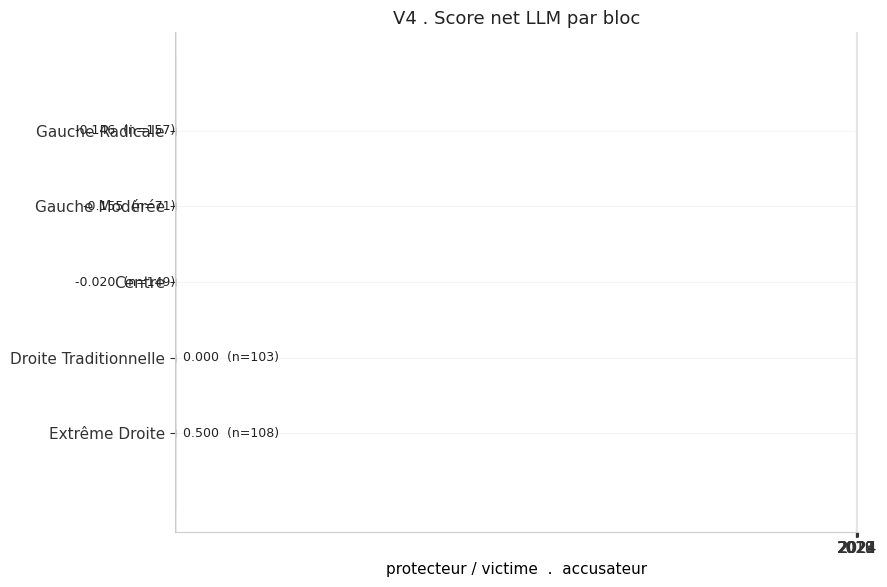

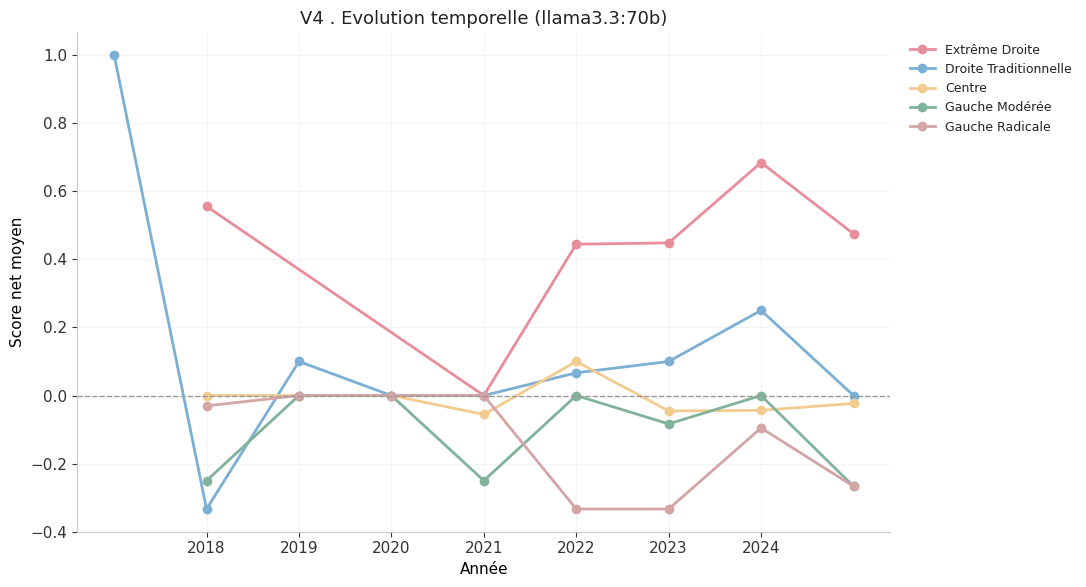

In [33]:
tracer_barres_empilees(df_v4, "cadrage_llm", f"V4 . Classification par LLM ({MODELE_CHOISI})")
tracer_score_net(df_v4, "score_net_v4", "V4 . Score net LLM par bloc")
tracer_evolution(df_v4, "score_net_v4", f"V4 . Evolution temporelle ({MODELE_CHOISI})")

### 5.6 Heatmap par parti et par année

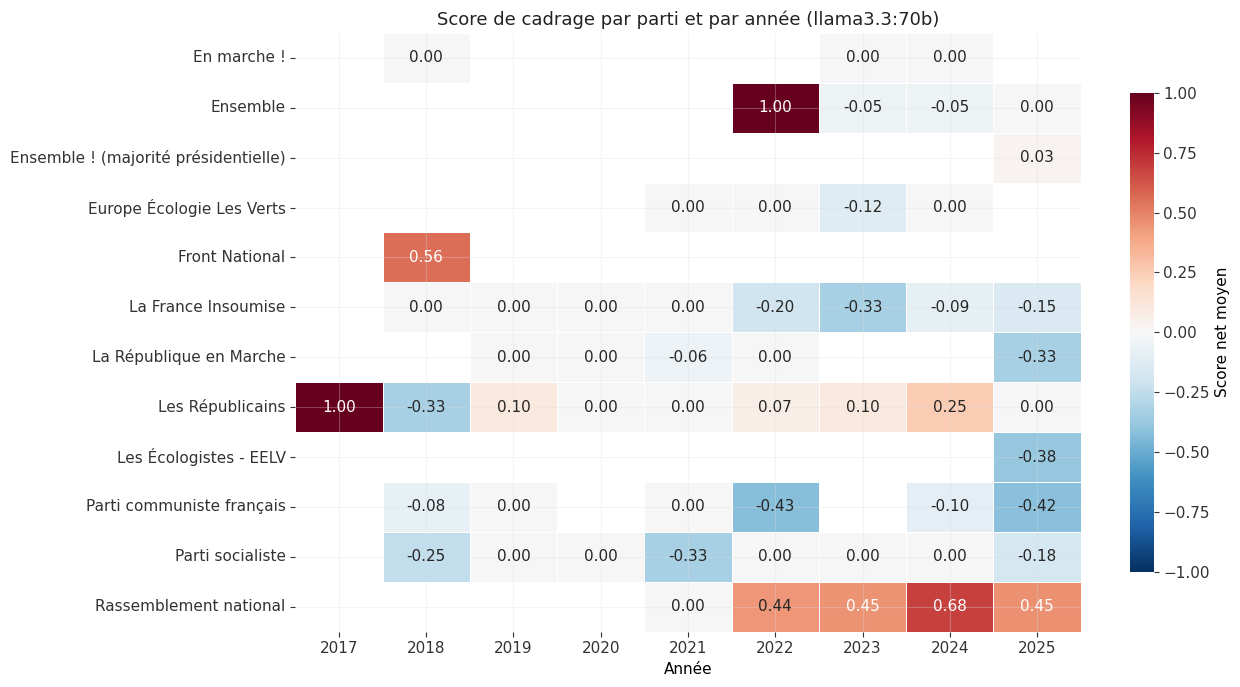

In [34]:
d = df_v4.copy()
d["date"] = pd.to_datetime(d["date"], errors="coerce")
d["annee"] = d["date"].dt.year.astype("Int64")
top_partis = d["nom_parti"].value_counts().head(12).index.tolist()
d_top = d[d["nom_parti"].isin(top_partis)]
pivot = d_top.groupby(["nom_parti", "annee"])["score_net_v4"].mean().unstack(fill_value=np.nan)

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.4, linecolor="white",
            cbar_kws={"label": "Score net moyen", "shrink": 0.8}, ax=ax)
ax.set_title(f"Score de cadrage par parti et par année ({MODELE_CHOISI})")
ax.set_xlabel("Année")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### 5.7 Validation qualitative

In [35]:
afficher_exemples(df_v4, "cadrage_llm", n=3)


VALIDATION QUALITATIVE

.................................................................
  EXTRÊME DROITE . 108 contextes
  {'ACCUSATEUR': 55, 'NEUTRE': 52, 'VICTIME': 1}

  [ACCUSATEUR]
    [Front National] "Le récent viol d’une personne âgée par un mineur de seize ans est une abomination qui doit entraîner l’expulsion du mineur étranger dès qu’il aura été jugé..."
    > L'orateur relie directement la nationalité du mineur à la nécessité d'expulsion après jugement, suggérant une causalité entre l'immigration et la comm
    [Front National] "Par cet amendement, nous proposons d’expulser systématiquement tout étranger coupable d’une agression sexuelle..."
    > L'orateur propose une mesure visant à expulser les étrangers coupables d'agressions sexuelles, ce qui implique un lien entre l'immigration et les viol
    [Front National] "Par cet amendement, nous proposons d’expulser systématiquement tout étranger coupable d’une agression sexuelle Les faits divers de cet ordre se multiplient,

## 5bis. Methode V4b . LLM One-Shot Learning

### Pourquoi le one-shot ?

Le zero-shot (V4) donne parfois des classifications incorrectes parce que le LLM n'a
aucun exemple concret de ce qu'on attend. Le **one-shot learning** consiste a inclure
un exemple annoté dans le prompt, avant la phrase a classifier. Le LLM peut alors
s'appuyer sur cet exemple pour calibrer ses réponses.

On reprend exactement la meme architecture que V4 (meme API, meme prompt systeme)
mais on ajoute un échange user/assistant dans l'historique de conversation pour montrer
au modèle a quoi ressemble une bonne classification.

In [152]:
# Exemple one-shot (issu de l'annotation manuelle)
PROMPT_ONE = "La peur des insultes, menaces, agressions en pleine rue, d'un retour des ratonnades, est très présente parmi les musulmans de France, qui ne se sentent plus en sécurité"
RATING_ONE = ("ANALYSE : les personnes immigrées ou les minorités sont victimes de violences \n"
              "CATEGORIE : VICTIME")
BASE_URL = "https://llm.lab.groupe-genes.fr"


def appeler_llm_oneshot(prompt_user, max_retries=6):
    payload = {
        "model": "mistral:latest",
        "messages": [
            {"role": "assistant", "content": PROMPT_SYSTEME},
            {"role": "user", "content": PROMPT_ONE},
            {"role": "assistant", "content": RATING_ONE},
            {"role": "user", "content": prompt_user},
        ],
        "stream": False,
        "options": {"temperature": 0.0},
    }

    r = requests.post(
        f"{BASE_URL}/ollama/api/chat",
        headers={"Authorization": f"Bearer {API_KEY}", "Content-Type": "application/json"},
        json=payload, timeout=120, verify=False)
    r.raise_for_status()
    return r.json()["message"]["content"]
        

print("Fonction one-shot prête.")

Fonction one-shot prête.


In [164]:
import os
import pandas as pd
import time
import csv
from tqdm import tqdm

output_v4b = "/home/onyxia/work/projet_eco_socio/analyses/cadrage_v4b_oneshot"
os.makedirs(output_v4b, exist_ok=True)
fichier_csv_1s = os.path.join(output_v4b, "phrases_classifiees_oneshot.csv")

# --- REPRISE ROBUSTE ---
deja = set()
cols = list(df_contextes.columns) + ['cadrage_1s', 'score_net_1s', 'justification', 'reponse_brute']

if os.path.exists(fichier_csv_1s):
    try:
        df_ex = pd.read_csv(fichier_csv_1s, on_bad_lines='skip', encoding='utf-8-sig')
        deja = set(df_ex['contexte'].dropna().tolist())
        print(f"Reprise : {len(deja)} contextes deja classifies.")

        # Réécriture clean
        df_ex.to_csv(fichier_csv_1s, index=False, encoding='utf-8-sig')

    except Exception as e:
        print(f"CSV corrompu ({e}), on repart de zero.")
        deja = set()

# --- INITIALISATION FICHIER ---
if not os.path.exists(fichier_csv_1s) or os.path.getsize(fichier_csv_1s) == 0:
    with open(fichier_csv_1s, 'w', newline='', encoding='utf-8-sig') as f:
        writer = csv.DictWriter(f, fieldnames=cols)
        writer.writeheader()

df_rest = df_contextes[~df_contextes['contexte'].isin(deja)]
print(f"{len(df_rest)} contextes restants.\n")

# --- BOUCLE AVEC ECRITURE INCREMENTALE ROBUSTE ---
erreurs_consecutives = 0
with open(fichier_csv_1s, 'a', newline='', encoding='utf-8-sig') as f:
    writer = csv.DictWriter(f, fieldnames=cols)

    for _, row in tqdm(df_rest.iterrows(), total=len(df_rest), desc="One-Shot"):

        prompt = f"Parti : '{row['nom_parti']}'\nContexte :\n\"{row['contexte']}\"\n\nFournis ton ANALYSE puis ta CATEGORIE."
        reponse = appeler_llm_oneshot(prompt)
        if not reponse:
            print("⚠️ reponse vide")

        if not reponse:
            erreurs_consecutives += 1
            if erreurs_consecutives >= 10:
                print("\n10 erreurs consecutives. Arret de securite.")
                break
            continue

        erreurs_consecutives = 0

        cadrage, score, justif = parser_reponse(reponse)

        ligne = row.to_dict()
        ligne.update({
            'cadrage_1s': cadrage,
            'score_net_1s': score,
            'justification': justif,
            'reponse_brute': reponse
        })

        # écriture directe
        writer.writerow(ligne)

        # flush réel disque
        f.flush()
        os.fsync(f.fileno())

        time.sleep(0.5)

# --- CHARGEMENT FINAL ---
df_v4b = pd.read_csv(fichier_csv_1s, on_bad_lines='skip', encoding='utf-8-sig')

df_v4b['cadrage_1s'] = df_v4b['cadrage_1s'].astype(str).str.upper().str.strip()
df_v4b['cadrage_1s'] = df_v4b['cadrage_1s'].where(
    df_v4b['cadrage_1s'].isin(['ACCUSATEUR','VICTIME','NEUTRE']),
    'NEUTRE'
)

df_v4b['score_net_1s'] = df_v4b['cadrage_1s'].map({
    'ACCUSATEUR': 1,
    'VICTIME': -1,
    'NEUTRE': 0
})

print(f"\nV4b terminée : {len(df_v4b)} contextes.")
print(df_v4b['cadrage_1s'].value_counts().to_string())

Reprise : 17 contextes deja classifies.
571 contextes restants.



One-Shot: 100%|██████████| 571/571 [16:03<00:00,  1.69s/it]


V4b terminée : 588 contextes.
cadrage_1s
ACCUSATEUR    258
NEUTRE        228
VICTIME       102


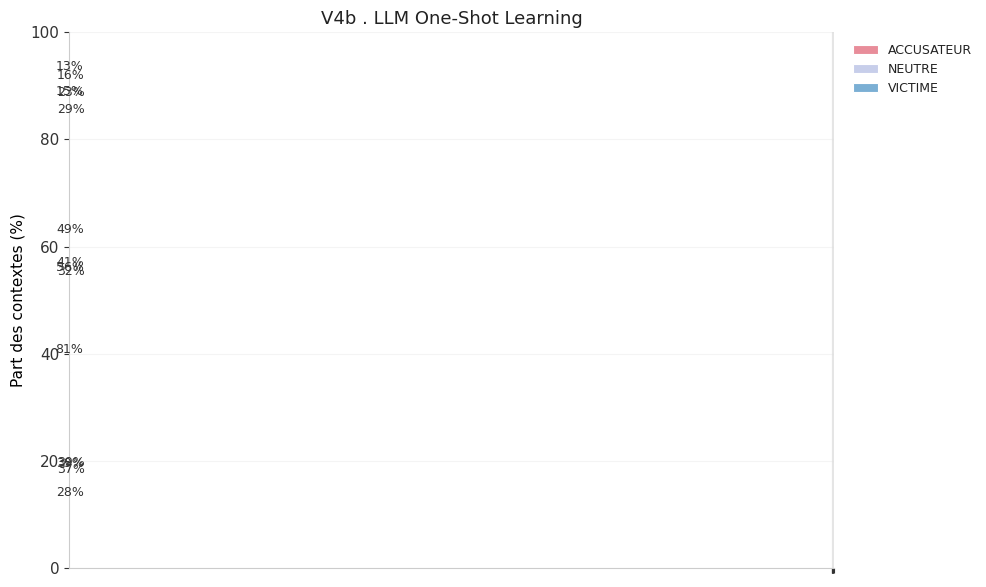

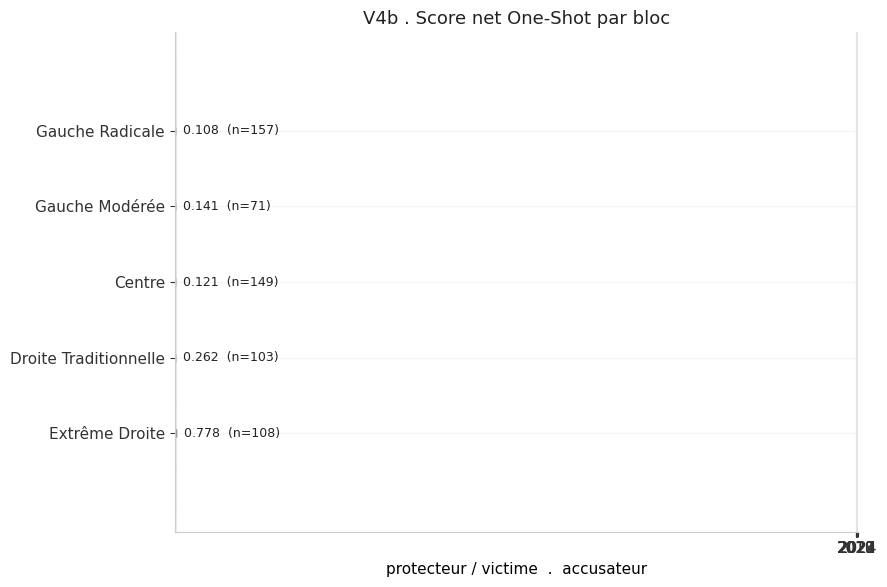

In [165]:
tracer_barres_empilees(df_v4b, "cadrage_1s", "V4b . LLM One-Shot Learning")
tracer_score_net(df_v4b, "score_net_1s", "V4b . Score net One-Shot par bloc")

## 5ter. Methode V4c . LLM Few-Shot Learning (5 exemples)

Le few-shot pousse la logique du one-shot plus loin : on fournit **5 exemples annotés**
couvrant les 3 catégories (ACCUSATEUR, VICTIME, NEUTRE). Le LLM a ainsi une meilleure
compréhension de ce qu'on attend pour chaque catégorie, y compris les cas limites.

Les exemples sont choisis manuellement pour couvrir les cas ambigüs :
un fait divers administratif (NEUTRE), une accusation explicite (ACCUSATEUR),
une défense des immigrés (VICTIME), etc.

In [166]:
# 5 exemples annotés manuellement pour le few-shot
FEW_SHOT_EXAMPLES = [
    {
        "user": "Mais combien de Mila inconnues ont besoin de notre soutien face à la violence de l'islam radical",
        "assistant": "ANALYSE : l'orateur présente l'islam comme source de violence\nCATEGORIE : ACCUSATEUR"
    },
    {
        "user": "J'en profite pour vous alerter : il n'y a pas si longtemps, de nombreux étrangers sont arrivés en France parce qu'ils étaient pourchassés ou victimes de discriminations, notamment pendant la seconde guerre mondiale",
        "assistant": "ANALYSE : les étrangers sont présentés comme victimes de persécutions\nCATEGORIE : VICTIME"
    },
    {
        "user": "La peur des insultes, menaces, agressions en pleine rue, d'un retour des ratonnades, est très présente parmi les musulmans de France, qui ne se sentent plus en sécurité",
        "assistant": "ANALYSE : les musulmans sont décrits comme victimes de violences\nCATEGORIE : VICTIME"
    },
    {
        "user": "Par ailleurs, il me semble aussi tout à fait normal de prononcer une peine d'interdiction du territoire français à l'égard d'un étranger qui a agressé un élu",
        "assistant": "ANALYSE : l'orateur lie l'étranger a une agression commise\nCATEGORIE : ACCUSATEUR"
    },
    {
        "user": "Le 11 octobre 2022, un migrant sous le coup d'une OQTF est interpellé et mis en prison car il est suspecté d'avoir violemment agressé un homme à Brest fin juillet 2022",
        "assistant": "ANALYSE : fait divers administratif, constat factuel\nCATEGORIE : NEUTRE"
    },
]




def appeler_llm_fewshot(prompt_user, max_retries=6):
    messages = [{"role": "system", "content": PROMPT_SYSTEME}]
    for ex in FEW_SHOT_EXAMPLES:
        messages.append({"role": "user", "content": ex["user"]})
        messages.append({"role": "assistant", "content": ex["assistant"]})
    messages.append({"role": "user", "content": prompt_user})

    payload = {"model": MODELE_CHOISI, "messages": messages,
               "stream": False, "options": {"temperature": 0.0}}
    for attempt in range(max_retries):
        try:
            r = requests.post(f"{BASE_URL}/ollama/api/chat",
                headers={"Authorization": f"Bearer {API_KEY}", "Content-Type": "application/json"},
                json=payload, timeout=120)
            r.raise_for_status()
            return r.json()["message"]["content"]
        except requests.exceptions.HTTPError as e:
            if e.response.status_code == 504: time.sleep(60)
            else: time.sleep(15)
        except requests.exceptions.RequestException:
            time.sleep(30)
        except ValueError:
            time.sleep(15)
    return ""

print("Fonction few-shot prête (5 exemples).")

Fonction few-shot prête (5 exemples).


In [168]:
output_v4c = "/home/onyxia/work/projet_eco_socio/analyses/cadrage_v4c_fewshot"
os.makedirs(output_v4c, exist_ok=True)
fichier_csv_fs = os.path.join(output_v4c, "phrases_classifiees_fewshot.csv")

deja_fs = []
if os.path.exists(fichier_csv_fs):
    df_ex = pd.read_csv(fichier_csv_fs)
    deja_fs = df_ex['contexte'].tolist()
    print(f"Reprise : {len(deja_fs)} contextes deja classifies.")
else:
    cols = list(df_contextes.columns) + ['cadrage_fs', 'score_net_fs', 'justification', 'reponse_brute']
    pd.DataFrame(columns=cols).to_csv(fichier_csv_fs, index=False, encoding='utf-8-sig')

df_rest_fs = df_contextes[~df_contextes['contexte'].isin(deja_fs)]
print(f"{len(df_rest_fs)} contextes restants.\n")

for _, row in tqdm(df_rest_fs.iterrows(), total=len(df_rest_fs), desc="Few-Shot"):
    prompt = f"Parti : '{row['nom_parti']}'\nContexte :\n\"{row['contexte']}\"\n\nFournis ton ANALYSE puis ta CATEGORIE."
    reponse = appeler_llm_fewshot(prompt)
    if not reponse: continue
    cadrage, score, justif = parser_reponse(reponse)
    ligne = row.to_dict()
    ligne.update({'cadrage_fs': cadrage, 'score_net_fs': score, 'justification': justif, 'reponse_brute': reponse})
    pd.DataFrame([ligne]).to_csv(fichier_csv_fs, mode='a', header=False, index=False, encoding='utf-8-sig')
    time.sleep(0.5)

df_v4c = pd.read_csv(fichier_csv_fs)
df_v4c['cadrage_fs'] = df_v4c['cadrage_fs'].astype(str).str.upper().str.strip()
df_v4c['cadrage_fs'] = df_v4c['cadrage_fs'].where(df_v4c['cadrage_fs'].isin(['ACCUSATEUR','VICTIME','NEUTRE']), 'NEUTRE')
df_v4c['score_net_fs'] = df_v4c['cadrage_fs'].map({'ACCUSATEUR':1,'VICTIME':-1,'NEUTRE':0})
print(f"\nV4c terminée : {len(df_v4c)} contextes.")
print(df_v4c['cadrage_fs'].value_counts().to_string())

Reprise : 0 contextes deja classifies.
588 contextes restants.



Few-Shot:  22%|██▏       | 127/588 [6:25:44<23:20:13, 182.24s/it]


KeyboardInterrupt: 

In [ ]:
tracer_barres_empilees(df_v4c, "cadrage_fs", "V4c . LLM Few-Shot (5 exemples)")
tracer_score_net(df_v4c, "score_net_fs", "V4c . Score net Few-Shot par bloc")
tracer_evolution(df_v4c, "score_net_fs", "V4c . Evolution temporelle Few-Shot")

## 5quater. Methode V5 . Analyse de sentiment CamemBERT

Cette méthode est différente des précédentes : au lieu de classifier le cadrage,
on mesure le **sentiment** (positif/négatif) des phrases de cooccurrence VSS x immigration.
L'hypothèse est que l'extreme droite utilise un ton plus négatif/hostile quand elle
parle d'immigration dans le contexte des VSS.

On utilise le modèle `tblard/tf-camembert-base-french-sentiment` fine-tuné sur des avis
en francais. C'est un classificateur binaire (POSITIF/NEGATIF) avec un score de confiance.

In [163]:
try:
    from transformers import pipeline as hf_pipeline
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "transformers", "torch"])
    from transformers import pipeline as hf_pipeline

import torch

chemin_v5 = "/home/onyxia/work/projet_eco_socio/analyses/cadrage_v5_sentiment.pkl"

if os.path.exists(chemin_v5):
    df_v5 = pd.read_pickle(chemin_v5)
    print(f"Resultats V5 charges : {len(df_v5)} contextes.")
else:
    print("Chargement du modèle de sentiment francais...")
    try:
        pipe_sent = hf_pipeline("text-classification",
                                model="nlptown/bert-base-multilingual-uncased-sentiment",
                                tokenizer="camembert-base",
                                device=0 if torch.cuda.is_available() else -1,
                                truncation=True, max_length=512)
        print("Modèle chargé.")
    except Exception as e:
        print(f"Erreur : {e}")
        pipe_sent = None

    if pipe_sent:
        df_v5 = df_contextes.copy()
        sentiments = []
        for _, row in tqdm(df_v5.iterrows(), total=len(df_v5), desc="Sentiment"):
            try:
                pred = pipe_sent(row['contexte'][:512])
                sentiments.append(pred[0])
            except:
                sentiments.append({"label": "UNKNOWN", "score": 0.5})

        df_v5['sentiment_label'] = [s['label'] for s in sentiments]
        df_v5['sentiment_score'] = [s['score'] for s in sentiments]

        def normaliser_label(label):
            label = str(label).upper()
            if any(x in label for x in ["NEG", "0", "1 STAR", "NEGATIVE"]): return "NEGATIF"
            elif any(x in label for x in ["POS", "1", "5 STAR", "POSITIVE"]): return "POSITIF"
            return "NEUTRE"

        df_v5['sentiment'] = df_v5['sentiment_label'].apply(normaliser_label)
        df_v5.to_pickle(chemin_v5)
    else:
        df_v5 = df_contextes.copy()
        df_v5['sentiment'] = "UNKNOWN"

print(df_v5['sentiment'].value_counts().to_string())

Chargement du modèle de sentiment francais...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6857.45it/s]


Modèle chargé.


Sentiment: 100%|██████████| 588/588 [05:28<00:00,  1.79it/s]

sentiment
NEGATIF    520
NEUTRE      67
POSITIF      1


/tmp/ipykernel_1412/4034043235.py:15: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


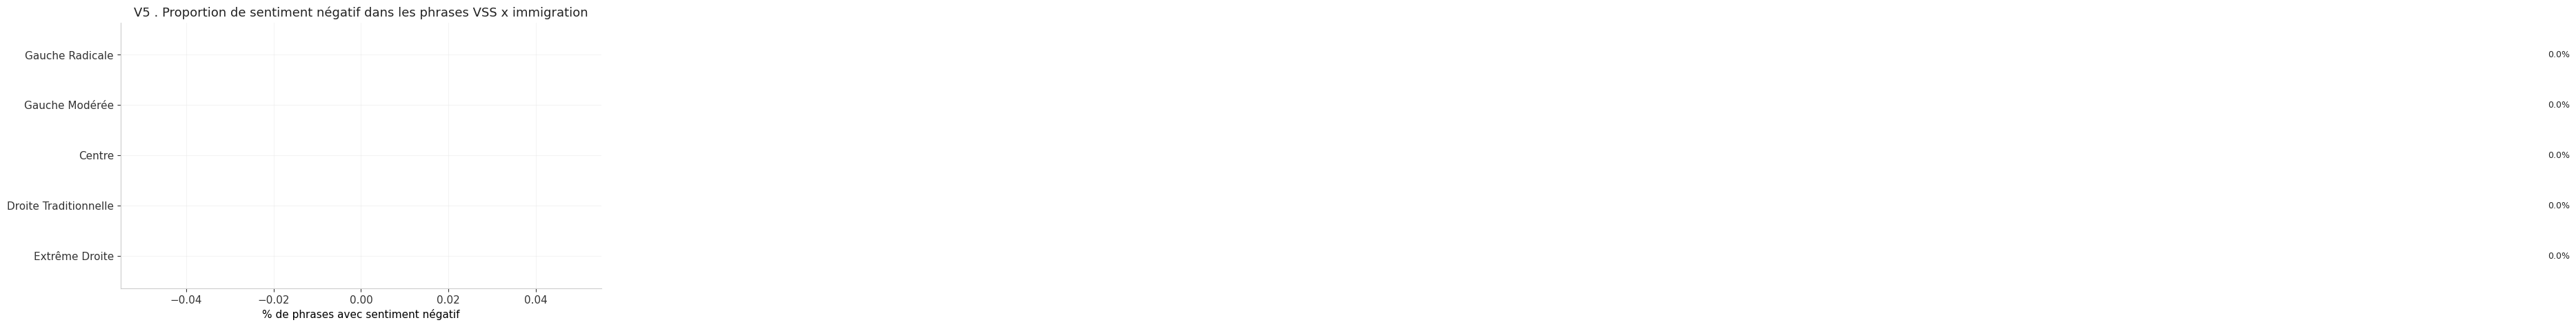

In [160]:
# Proportion de sentiment negatif par bloc
sent_bloc = df_v5.groupby('bloc')['sentiment'].apply(
    lambda x: (x == 'NEGATIF').mean() * 100).reset_index(name='pct_negatif')
sent_bloc = sent_bloc[sent_bloc['bloc'].isin(ORDRE_BLOCS)]
sent_bloc['bloc'] = pd.Categorical(sent_bloc['bloc'], categories=ORDRE_BLOCS, ordered=True)
sent_bloc = sent_bloc.sort_values('bloc')

fig, ax = plt.subplots(figsize=(9, 5))
colors = [COULEURS_BLOCS[b] for b in sent_bloc['bloc']]
ax.barh(sent_bloc['bloc'], sent_bloc['pct_negatif'], color=colors, edgecolor='white', lw=0.8)
for i, row in enumerate(sent_bloc.itertuples()):
    ax.text(row.pct_negatif + 0.5, i, f"{row.pct_negatif:.1f}%", va='center', fontsize=9)
ax.set_xlabel("% de phrases avec sentiment négatif")
ax.set_title("V5 . Proportion de sentiment négatif dans les phrases VSS x immigration")
plt.tight_layout()
plt.show()

## 7. Annotation manuelle (gold standard)

### Pourquoi annoter manuellement ?

Aucune des méthodes V1 a V5 ne produit une "vérité absolue". Pour savoir laquelle est
la plus fiable, il faut comparer leurs résultats a un **gold standard** : un échantillon
de phrases annotées manuellement par un humain (vous).

C'est une pratique standard en NLP, l'idée est d'annoter un échantillon aléatoire de ~50-100 phrases, puis de calculer des
métriques de performance (accuracy, precision, recall, F1) pour chaque méthode.

### Comment ca marche

1. On tire un échantillon aléatoire stratifié (meme nombre par bloc)
2. On affiche chaque phrase avec son contexte
3. Vous annotez manuellement : ACCUSATEUR, VICTIME ou NEUTRE
4. On sauvegarde vos annotations dans un CSV
5. On compare chaque méthode a vos annotations

Le CSV d'annotations est persistant : si on relance le notebook, les annotations qu'on a faites sont conservées.

In [ ]:
# Tirage de l'echantillon a annoter
chemin_gold = "/home/onyxia/work/projet_eco_socio/analyses/gold_standard_annotations.csv"

N_PAR_BLOC = 10  # 10 phrases par bloc = 50 phrases au total

if os.path.exists(chemin_gold):
    df_gold = pd.read_csv(chemin_gold)
    print(f"Annotations existantes chargées : {len(df_gold)} phrases.")
    n_annote = df_gold['annotation_humaine'].notna().sum()
    print(f"  dont {n_annote} deja annotées.")
else:
    # Echantillon stratifié
    echantillons = []
    for bloc in ORDRE_BLOCS:
        sub = df_contextes[df_contextes['bloc'] == bloc]
        n = min(N_PAR_BLOC, len(sub))
        if n > 0:
            echantillons.append(sub.sample(n=n, random_state=42))
    df_gold = pd.concat(echantillons, ignore_index=True)
    df_gold['annotation_humaine'] = None  # colonne a remplir
    df_gold['commentaire'] = None
    df_gold.to_csv(chemin_gold, index=False, encoding='utf-8-sig')
    print(f"Echantillon créé : {len(df_gold)} phrases a annoter.")
    print(f"Fichier : {chemin_gold}")

### Interface d'annotation

On exécute la cellule suivante pour annoter les phrases une par une.
Pour chaque phrase, tapez :
- `A` pour ACCUSATEUR
- `V` pour VICTIME
- `N` pour NEUTRE
- `S` pour passer (skip)
- `Q` pour quitter et sauvegarder

In [ ]:
def annoter_gold_standard(chemin_csv):
    df = pd.read_csv(chemin_csv)
    n_total = len(df)
    n_fait = df['annotation_humaine'].notna().sum()
    print(f"{n_fait}/{n_total} phrases deja annotées.\n")

    mapping = {'A': 'ACCUSATEUR', 'V': 'VICTIME', 'N': 'NEUTRE'}

    for idx, row in df.iterrows():
        if pd.notna(row.get('annotation_humaine')):
            continue

        print(f"\n{'='*70}")
        print(f"Phrase {idx+1}/{n_total} | Bloc : {row['bloc']} | Parti : {row.get('nom_parti', '?')}")
        print(f"{'='*70}")
        print(f"\n  \"{row['contexte'][:500]}\"\n")
        print("  [A] ACCUSATEUR  [V] VICTIME  [N] NEUTRE  [S] Passer  [Q] Quitter")

        choix = input("  Votre annotation : ").strip().upper()

        if choix == 'Q':
            df.to_csv(chemin_csv, index=False, encoding='utf-8-sig')
            print(f"\nSauvegardé. {df['annotation_humaine'].notna().sum()}/{n_total} annotées.")
            return df
        elif choix == 'S':
            continue
        elif choix in mapping:
            df.at[idx, 'annotation_humaine'] = mapping[choix]
            # Sauvegarde immediate
            df.to_csv(chemin_csv, index=False, encoding='utf-8-sig')
        else:
            print("  Choix non reconnu, on passe.")

    print(f"\nAnnotation terminée. {df['annotation_humaine'].notna().sum()}/{n_total} annotées.")
    df.to_csv(chemin_csv, index=False, encoding='utf-8-sig')
    return df

df_gold = annoter_gold_standard(chemin_gold)

## 8. Evaluation comparative (métriques de performance)

### Comment comparer objectivement les méthodes ?

On utilise les métriques standard de classification supervisée, calculées sur
l'échantillon annoté manuellement :

- **Accuracy** : % de phrases correctement classifiées
- **Precision** par classe : parmi les phrases classées X, combien le sont vraiment ?
- **Recall** par classe : parmi les vraies phrases X, combien ont été trouvées ?
- **F1-score** : moyenne harmonique de precision et recall
- **Kappa de Cohen** : mesure l'accord au-dela du hasard (kappa > 0.6 = bon accord)

Ces métriques sont calculées séparément pour chaque méthode (V1 a V4c),
ce qui permet de voir laquelle s'approche le plus du jugement humain.

C'est la démarche standard en NLP computationnel pour évaluer des classifieurs
de texte .

In [ ]:
from sklearn.metrics import classification_report, cohen_kappa_score, confusion_matrix, accuracy_score

def evaluer_methode(df_gold, col_methode, nom_methode):
    """Compare une methode au gold standard humain."""
    # Jointure sur le contexte
    df_eval = df_gold[df_gold['annotation_humaine'].notna()].copy()
    if col_methode not in df_eval.columns:
        # Joindre depuis le df de la methode
        return None

    df_eval = df_eval[df_eval[col_methode].notna()]
    if len(df_eval) < 5:
        print(f"{nom_methode} : pas assez de donnees pour evaluer (n={len(df_eval)})")
        return None

    y_true = df_eval['annotation_humaine'].values
    y_pred = df_eval[col_methode].values

    acc = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)

    print(f"\n{'='*60}")
    print(f"  {nom_methode}")
    print(f"{'='*60}")
    print(f"  Accuracy : {acc:.3f}")
    print(f"  Kappa    : {kappa:.3f}")
    print(f"  n        : {len(df_eval)}")
    print(f"\n{classification_report(y_true, y_pred, zero_division=0)}")

    return {'methode': nom_methode, 'accuracy': acc, 'kappa': kappa, 'n': len(df_eval)}

print("Fonction d'evaluation prête.")

In [ ]:
# Fusion du gold standard avec les predictions de chaque methode
df_gold = pd.read_csv(chemin_gold)
df_gold_annote = df_gold[df_gold['annotation_humaine'].notna()].copy()
print(f"{len(df_gold_annote)} phrases annotées dans le gold standard.\n")

if len(df_gold_annote) < 5:
    print("Il faut annoter au moins 5 phrases pour evaluer.")
    print("Decommentez la cellule d'annotation plus haut et annotez l'echantillon.")
else:
    # Joindre les predictions de chaque methode
    for df_m, col_src, col_dst in [
        (df_v1, 'cadrage_v1', 'pred_v1'),
        (df_v2, 'cadrage_v2', 'pred_v2'),
        (df_v3, 'cadrage_v3', 'pred_v3'),
        (df_v4, 'cadrage_llm', 'pred_v4'),
    ]:
        mapping = df_m.set_index('contexte')[col_src].to_dict()
        df_gold_annote[col_dst] = df_gold_annote['contexte'].map(mapping)

    # Joindre V4b et V4c si disponibles
    try:
        mapping_1s = df_v4b.set_index('contexte')['cadrage_1s'].to_dict()
        df_gold_annote['pred_v4b'] = df_gold_annote['contexte'].map(mapping_1s)
    except: pass
    try:
        mapping_fs = df_v4c.set_index('contexte')['cadrage_fs'].to_dict()
        df_gold_annote['pred_v4c'] = df_gold_annote['contexte'].map(mapping_fs)
    except: pass

    # Evaluation
    resultats_eval = []
    for col, nom in [('pred_v1', 'V1 . Lexique'), ('pred_v2', 'V2 . Regex'),
                     ('pred_v3', 'V3 . Zero-Shot'), ('pred_v4', 'V4 . LLM Zero-Shot'),
                     ('pred_v4b', 'V4b . LLM One-Shot'), ('pred_v4c', 'V4c . LLM Few-Shot')]:
        if col in df_gold_annote.columns:
            r = evaluer_methode(df_gold_annote, col, nom)
            if r: resultats_eval.append(r)

    if resultats_eval:
        df_eval = pd.DataFrame(resultats_eval)
        print("\n\nRESUME COMPARATIF")
        print("=" * 60)
        print(df_eval.sort_values('accuracy', ascending=False).to_string(index=False))

In [ ]:
# Graphique comparatif des méthodes
if len(df_gold_annote) >= 5 and resultats_eval:
    df_eval = pd.DataFrame(resultats_eval)
    df_eval = df_eval.sort_values('accuracy', ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    colors_m = [PALETTE_PASTEL[i % len(PALETTE_PASTEL)] for i in range(len(df_eval))]
    axes[0].barh(df_eval['methode'], df_eval['accuracy'], color=colors_m, edgecolor='white', lw=0.8)
    for i, row in enumerate(df_eval.itertuples()):
        axes[0].text(row.accuracy + 0.01, i, f"{row.accuracy:.3f}", va='center', fontsize=9)
    axes[0].set_xlabel("Accuracy")
    axes[0].set_title("Accuracy par methode (vs annotation humaine)")
    axes[0].set_xlim(0, 1)

    # Kappa
    axes[1].barh(df_eval['methode'], df_eval['kappa'], color=colors_m, edgecolor='white', lw=0.8)
    for i, row in enumerate(df_eval.itertuples()):
        axes[1].text(max(0, row.kappa) + 0.01, i, f"{row.kappa:.3f}", va='center', fontsize=9)
    axes[1].set_xlabel("Kappa de Cohen")
    axes[1].set_title("Accord inter-annotateur (vs humain)")
    axes[1].set_xlim(-0.1, 1)
    axes[1].axvline(0.6, color='#999', ls='--', lw=0.8, label='Seuil bon accord (0.6)')
    axes[1].legend()

    plt.suptitle("Comparaison des methodes de classification du cadrage VSS x immigration", fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Pas assez d'annotations pour le graphique comparatif.")

### Matrice de confusion par méthode

Pour chaque méthode, la matrice de confusion montre exactement ou elle se trompe :
confond-elle des ACCUSATEUR avec des NEUTRE ? Des VICTIME avec des ACCUSATEUR ?

In [ ]:
if len(df_gold_annote) >= 5 and resultats_eval:
    methodes_dispo = [(col, nom) for col, nom in
        [('pred_v1','V1'), ('pred_v2','V2'), ('pred_v3','V3'),
         ('pred_v4','V4'), ('pred_v4b','V4b'), ('pred_v4c','V4c')]
        if col in df_gold_annote.columns and df_gold_annote[col].notna().sum() >= 5]

    n_plots = len(methodes_dispo)
    if n_plots > 0:
        fig, axes = plt.subplots(1, min(n_plots, 3), figsize=(5*min(n_plots,3), 4))
        if n_plots == 1: axes = [axes]

        labels = ['ACCUSATEUR', 'NEUTRE', 'VICTIME']
        for idx, (col, nom) in enumerate(methodes_dispo[:3]):
            df_sub = df_gold_annote[df_gold_annote[col].notna()]
            cm = confusion_matrix(df_sub['annotation_humaine'], df_sub[col], labels=labels)
            sns.heatmap(cm, annot=True, fmt='d', cmap='BuPu',
                        xticklabels=labels, yticklabels=labels, ax=axes[idx],
                        linewidths=0.5, linecolor='white')
            axes[idx].set_title(f"{nom}")
            axes[idx].set_ylabel("Vérité (humain)")
            axes[idx].set_xlabel("Prediction")

        plt.suptitle("Matrices de confusion (gold standard vs predictions)")
        plt.tight_layout()
        plt.show()

        # S'il y a plus de 3 methodes, deuxieme ligne
        if n_plots > 3:
            fig2, axes2 = plt.subplots(1, min(n_plots-3, 3), figsize=(5*min(n_plots-3,3), 4))
            if n_plots - 3 == 1: axes2 = [axes2]
            for idx, (col, nom) in enumerate(methodes_dispo[3:6]):
                df_sub = df_gold_annote[df_gold_annote[col].notna()]
                cm = confusion_matrix(df_sub['annotation_humaine'], df_sub[col], labels=labels)
                sns.heatmap(cm, annot=True, fmt='d', cmap='BuPu',
                            xticklabels=labels, yticklabels=labels, ax=axes2[idx],
                            linewidths=0.5, linecolor='white')
                axes2[idx].set_title(f"{nom}")
                axes2[idx].set_ylabel("Vérité (humain)")
                axes2[idx].set_xlabel("Prediction")
            plt.tight_layout()
            plt.show()

## 9. Synthèse comparative de toutes les méthodes

On rassemble ici les résultats de toutes les méthodes (V1 a V5) sur les memes données.


In [ ]:
print("SYNTHESE COMPARATIVE DES 4 METHODES")
print("=" * 80)

methodes_all = [("V1 . Lexique", df_v1, "cadrage_v1"),
                    ("V2 . Regex", df_v2, "cadrage_v2"),
                    ("V3 . Zero-Shot", df_v3, "cadrage_v3"),
                    ("V4 . LLM", df_v4, "cadrage_llm")]
    try: methodes_all.append(("V4b . One-Shot", df_v4b, "cadrage_1s"))
    except: pass
    try: methodes_all.append(("V4c . Few-Shot", df_v4c, "cadrage_fs"))
    except: pass
    for nom, df_m, col in methodes_all:
    print(f"\n{nom}")
    print("-" * 40)
    for bloc in ORDRE_BLOCS:
        sub = df_m[df_m["bloc"] == bloc]
        if sub.empty: continue
        n = len(sub)
        pct_acc = (sub[col] == "ACCUSATEUR").mean() * 100
        pct_vic = (sub[col] == "VICTIME").mean() * 100
        pct_neu = (sub[col] == "NEUTRE").mean() * 100
        print(f"  {bloc:30s} : ACC={pct_acc:5.1f}%  VIC={pct_vic:5.1f}%  NEU={pct_neu:5.1f}%  (n={n})")

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))
methodes = [("V1\nLexique", df_v1, "cadrage_v1"), ("V2\nRegex", df_v2, "cadrage_v2"),
            ("V3\nZero-Shot", df_v3, "cadrage_v3"), ("V4\nLLM", df_v4, "cadrage_llm")]
x = np.arange(len(ORDRE_BLOCS))
width = 0.18
colors_methods = ["#E88D9A", "#F2CC8F", "#7BAFD4", "#AA96DA"]

for i, (nom, df_m, col) in enumerate(methodes):
    pct_acc = []
    for bloc in ORDRE_BLOCS:
        sub = df_m[df_m["bloc"] == bloc]
        pct_acc.append((sub[col] == "ACCUSATEUR").mean() * 100 if len(sub) > 0 else 0)
    ax.bar(x + i * width, pct_acc, width, label=nom, color=colors_methods[i],
           edgecolor="white", linewidth=0.5)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(ORDRE_BLOCS, rotation=12, ha="right")
ax.set_ylabel("% de phrases classées ACCUSATEUR")
ax.set_title("Comparaison des 4 méthodes : taux de cadrage accusateur par bloc")
ax.legend(title="Methode")
plt.tight_layout()
plt.show()

## Conclusion

à compléter !
